# Classifier

In [1]:
import re
import matplotlib.pyplot as plt

def extract_accuracies(log_path):
    """
    Extracts per-epoch train and test accuracies from a log file.

    Parameters:
        log_path (str): Path to the log file.

    Returns:
        epochs (list[int]), train_acc (list[float]), test_acc (list[float])
    """
    pattern = re.compile(r"\[\s*(\d+)\]\s+train:\s+([\d.]+)%\s+test:\s+([\d.]+)%")
    epochs, train_acc, test_acc = [], [], []

    with open(log_path, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                epoch = int(match.group(1))
                train = float(match.group(2))
                test = float(match.group(3))
                epochs.append(epoch)
                train_acc.append(train)
                test_acc.append(test)

    return epochs, train_acc, test_acc

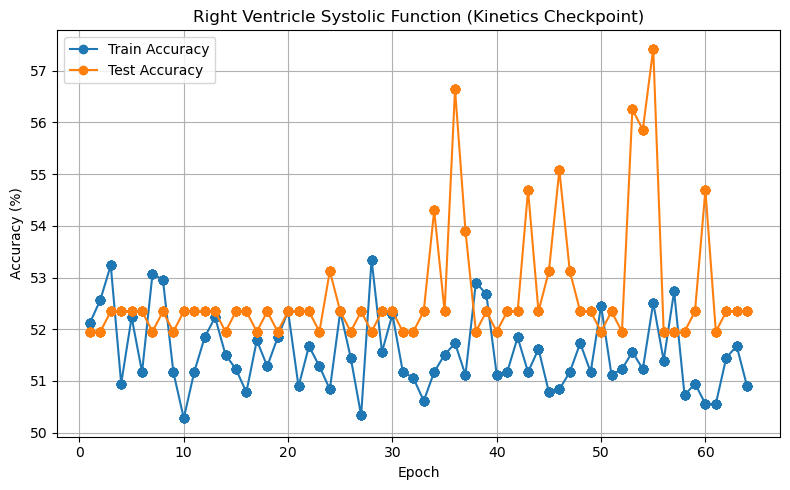

In [10]:
log_file1 = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_kinetics_0812_v1.log"
epochs1, train_acc1, test_acc1 = extract_accuracies(log_file1)
title="Right Ventricle Systolic Function (Kinetics Checkpoint)"
plt.figure(figsize=(8, 5))
plt.plot(epochs1, train_acc1, label="Train Accuracy", marker="o")
plt.plot(epochs1, test_acc1, label="Test Accuracy", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title(title)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

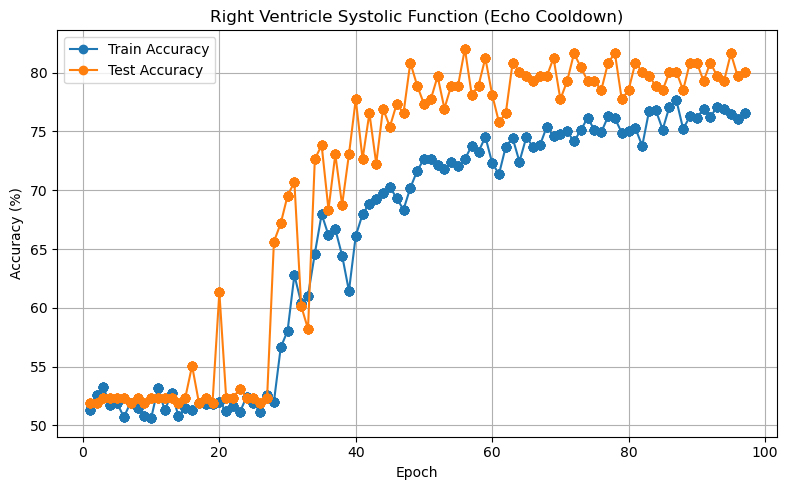

In [11]:
log_file1 = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_cooldown_0812_v1.log"
epochs1, train_acc1, test_acc1 = extract_accuracies(log_file1)
title="Right Ventricle Systolic Function (Echo Cooldown)"
plt.figure(figsize=(8, 5))
plt.plot(epochs1, train_acc1, label="Train Accuracy", marker="o")
plt.plot(epochs1, test_acc1, label="Test Accuracy", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title(title)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Pretraining

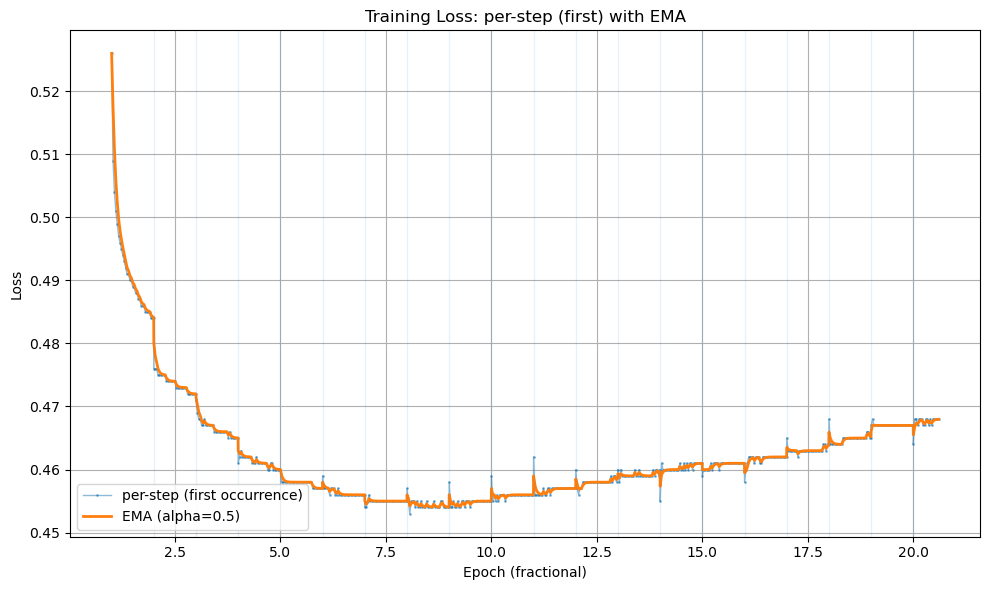

In [16]:
import re
from collections import OrderedDict
import numpy as np
import matplotlib.pyplot as plt

LOG_PATH = "/home/sagemaker-user/user-default-efs/vjepa2/cooldown-echo-336px-16f_logs_0820-v2.log"
ALPHA = 0.5  # EMA smoothing factor

# Regex: capture per-step losses; ignore "avg. loss" lines
STEP_PAT = re.compile(r"\[(\d+),\s*(\d+)\]\s+loss:\s+([0-9]*\.?[0-9]+)")

def extract_first_loss_per_step(log_path):
    """
    Return epochs, steps, losses for the FIRST occurrence of each (epoch, step),
    sorted by (epoch, step).
    """
    first = OrderedDict()  # preserves first-seen keys
    with open(log_path, "r") as f:
        for line in f:
            m = STEP_PAT.search(line)
            if not m:
                continue
            e, s, l = int(m.group(1)), int(m.group(2)), float(m.group(3))
            key = (e, s)
            if key not in first:
                first[key] = l

    items = sorted(first.items(), key=lambda kv: (kv[0][0], kv[0][1]))
    epochs = [e for (e, _), _ in items]
    steps  = [s for (_, s), _ in items]
    losses = [l for _, l in items]
    return epochs, steps, losses

def ema(values, alpha=0.01):
    """Exponential moving average (continuous across the run)."""
    out = []
    s = None
    for v in values:
        s = v if s is None else alpha * v + (1 - alpha) * s
        out.append(s)
    return out

# ---- parse logs ----
epochs, steps, losses = extract_first_loss_per_step(LOG_PATH)

# fractional epoch x-axis for monotonic plotting
max_step = max(steps) if steps else 1
x_steps = [e + s / (max_step + 1.0) for e, s in zip(epochs, steps)]

# compute EMA
losses_ema = ema(losses, alpha=ALPHA)

# ---- plot ----
plt.figure(figsize=(10, 6))
plt.plot(
    x_steps, losses,
    marker=".", linestyle="-",
    linewidth=1, markersize=2,
    alpha=0.5,  # 50% opacity for per-step curve
    label="per-step (first occurrence)"
)
plt.plot(
    x_steps, losses_ema,
    linewidth=2,
    label=f"EMA (alpha={ALPHA})"
)

# optional: vertical epoch boundaries
for e in sorted(set(epochs))[1:]:
    plt.axvline(e, alpha=0.1, linewidth=1)

plt.xlabel("Epoch (fractional)")
plt.ylabel("Loss")
plt.title("Training Loss: per-step (first) with EMA")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
